# Plot and animate data as view from above (Condensed)

In [2]:
import sys, os, glob
import matplotlib.pyplot as plt
import json
import pandas as pd
import numpy as np
import xarray as xr
xr.set_options(keep_attrs=True)
from matplotlib.colors import LogNorm, SymLogNorm
import matplotlib.dates as md
import multiprocessing
import shutil

from utilities.model_helpers import fetch_3d_data, convert_units_3d
from utilities.namelist_metadata import update_dataset_metadata
from utilities import new_fjet, new_fjet2, new_fjet3,  create_fade_cmap, set_name_tick_params
import utilities.tools as tools
import colormaps as pcmaps
from dask.diagnostics.progress import ProgressBar

In [3]:
idx_exp = 1
# cs_runs = [
#     ["cs-eriswil__20251125_114053", "50x40", 0, 191], # 50x40
#     ["cs-eriswil__20251129_230943", "50x40", 0, 191], # 50x40 ts 191  
#     ["cs-eriswil__20251209_001346", "200x160", 0, 191], # 200x160
# ]
cs_runs = [
    # ["cs-eriswil__20251129_230943", "50x40", 0, 191], 
    # ["cs-eriswil__20251125_114053", "50x40", 1, 191],    #C,  ccn400
    # ["cs-eriswil__20251209_001346", "200x160", 0, 191],  #C, ccn0
    # ["cs-eriswil__20251125_114053", "50x40", 0, 191],    #S, ccn0
    # ["cs-eriswil__20260121_131528", "50x40", 0, 229],    #S=1, ccn400
    # ["cs-eriswil__20260127_211338", "50x40", 0, 229],    #A=2, ccn400
    # ["cs-eriswil__20260127_211338", "50x40", 1, 229],    #P=3, ccn400
    # ["cs-eriswil__20260121_131528", "50x40", 1, 229],    #C=4, ccn400
#     ["cs-eriswil__20251209_001346", "200x160", 1, 191],  #S, ccn400
#     ["cs-eriswil__20260123_180947", "200x160", 0, 229],  #C, ccn0
#     ["cs-eriswil__20260123_180947", "200x160", 1, 229],  #C, ccn400
    ["cs-eriswil__20260210_113944", "50x40", 0, 334],
    ["cs-eriswil__20260210_113944", "50x40", 1, 334],
]

def flatten(xss):
    return [x for xs in xss for x in xs]


cs_run           = cs_runs[idx_exp][0]
cs_resolution    = cs_runs[idx_exp][1]
cs_run_idx       = cs_runs[idx_exp][2]

# Paths
model_data_root     = f'/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/'
processed_data_root = 'processed/'
png_path            = f'QL-TopView/{cs_run}/pngs/'

model_data_path  = f'{model_data_root}/RUN_ERISWILL_{cs_resolution}x100/ensemble_output/{cs_run}/'
extpar_file      = f'{model_data_root}/RUN_ERISWILL_{cs_resolution}x100/COS_in/extPar_Eriswil_{cs_resolution}.nc'





## Load data and setup

In [4]:

# Load metadata
flist_3d = sorted(glob.glob(model_data_path + '3D_??????????????.nc'))
exp_names = [f.split('/')[-1].split('_')[-1].split('.')[0] for f in flist_3d]

with open(glob.glob(model_data_path + "*.json")[0], "r") as jsonfile:
    meta = json.load(jsonfile)

flare_exp_name = [exp for exp in exp_names if meta[exp]['INPUT_ORG']['sbm_par']['lflare']][cs_run_idx]
flare_exp_nc_file = [f for f in flist_3d if flare_exp_name in f][0]
print(f"Flare run: {flare_exp_name}")

# Load and prepare 3D data
ds_3d = fetch_3d_data(flare_exp_nc_file, extpar_file, meta[flare_exp_name]['INPUT_ORG'], var_sets=['meteo', 'bulk', 'spec'], chunks={'time': 1})
ds_3d = update_dataset_metadata(ds_3d)
ds_3d = ds_3d.isel( altitude=slice(80, None))
ds_3d = convert_units_3d(ds_3d, ds_3d["rho"])



Flare run: 20260210114328


In [5]:
# Load external data
data_extpar = xr.open_mfdataset(extpar_file, chunks='auto')
lat2D  = data_extpar['lat'].values[7:-7, 7:-7]
lon2D  = data_extpar['lon'].values[7:-7, 7:-7]
height = data_extpar['HSURF'].values[7:-7, 7:-7] 

# Plot configuration
cfg = {
    'resolution': '400m' if '50x40' in meta[flare_exp_name]['domain'] else '100m',
    'resolution_deg': 0.004 if '50x40' in meta[flare_exp_name]['domain'] else 0.001,
    'dpi': 300,
    'pixel_size': (1920, 1080),
    'poolsize': 128,
    'plot_all_frames': True,
    
    # Coordinates
    'flare_lat': 47.07425, 
    'flare_lon': 7.90522,
    'origin_lat': 47.070522, 
    'origin_lon': 7.872991,
    'plot_xlim': (7.7671843, 7.94),
    'plot_ylim': (47.02, 47.12),
    'delta_x': float(1e3 * np.mean(np.diff(ds_3d.longitude.values)) * 111.13295254925466),  # 1 degree of longitude in km
    'delta_y': float(1e3 * np.mean(np.diff(ds_3d.latitude.values)) * 111.13295254925466),  # 1 degree of latitude in km
    'delta_t': float(np.mean(np.diff(ds_3d.time.astype('datetime64[s]')).astype(float))),
    'n_lon': ds_3d.longitude.size,
    'n_lat': ds_3d.latitude.size,
    'n_time': ds_3d.time.size,
    
    # Color limits
    'vel_lims': [-0.5, 0.5],
    'v_lims_qi': [1e-4, 1e0],
    
    # Font sizes
    'tick_size': 8,
    'axis_size': 9.5,
    'timer_size': 16.5,
}
cfg

{'resolution': '400m',
 'resolution_deg': 0.004,
 'dpi': 300,
 'pixel_size': (1920, 1080),
 'poolsize': 128,
 'plot_all_frames': True,
 'flare_lat': 47.07425,
 'flare_lon': 7.90522,
 'origin_lat': 47.070522,
 'origin_lon': 7.872991,
 'plot_xlim': (7.7671843, 7.94),
 'plot_ylim': (47.02, 47.12),
 'delta_x': 653.2575073242188,
 'delta_y': 444.7454528808594,
 'delta_t': 10.0,
 'n_lon': 36,
 'n_lat': 26,
 'n_time': 229,
 'vel_lims': [-0.5, 0.5],
 'v_lims_qi': [0.0001, 1.0],
 'tick_size': 8,
 'axis_size': 9.5,
 'timer_size': 16.5}

In [6]:
# Compute column-integrated data once
mod = ds_3d[['qi', 'qs', 'dz']].sel(  latitude=slice(None, cfg['flare_lat'] + 2.*cfg['resolution_deg']), 
                                      longitude=slice(None, cfg['flare_lon'] + 2.*cfg['resolution_deg']) )
mod_latlon = (mod[['qi', 'qs']] * mod['dz']).sum('altitude')

# prepare data for tobac quicklook
with ProgressBar() as pbar:
    mod_latlon = xr.where(mod_latlon < 1e-7, np.nan, mod_latlon).persist()
# plotting data
IWC = (mod_latlon['qi'] + mod_latlon['qs']).values

[########################################] | 100% Completed | 46.57 s


## Configuration

In [7]:
# Load tracking data
plot_time_frame = [np.datetime64('2023-01-25T12:20:00'), np.datetime64('2023-01-25T13:00:00')]
tracking_by_var = 'qi+qs'
tracks_csv    = tools.load_tracking_csv(f'{model_data_path}/{flare_exp_name}_qi+qs_tobac_track.csv')
tracks_csv_qi = tools.load_tracking_csv(f'{model_data_path}/{flare_exp_name}_qi_tobac_track.csv')
tracks_csv_qs = tools.load_tracking_csv(f'{model_data_path}/{flare_exp_name}_qs_tobac_track.csv')
cell_tracks    = [ group[1][pd.to_datetime(group[1]['time']) >= plot_time_frame[0]][::6] for group in tracks_csv.groupby("cell") ]
cell_tracks_qi = [ group[1][pd.to_datetime(group[1]['time']) >= plot_time_frame[0]][::6] for group in tracks_csv_qi.groupby("cell") ]
cell_tracks_qs = [ group[1][pd.to_datetime(group[1]['time']) >= plot_time_frame[0]][::6] for group in tracks_csv_qs.groupby("cell") ]

#cell_tracks_qi, cell_tracks_qs = None, None

## Plotting functions

In [8]:
def add_annotations(ax, cfg):
    from utilities import add_ruler
    """Add scatter points, ruler, and seeding paths."""
    # Scatter points
    ax.scatter(cfg['origin_lon'], cfg['origin_lat'], s=70, marker='x', color='red', zorder=2)
    ax.scatter(cfg['flare_lon'],  cfg['flare_lat'],  s=50, marker='o', facecolor='none', edgecolor='white', linewidth=2.5, zorder=2)
    ax.scatter(cfg['flare_lon'],  cfg['flare_lat'],  s=50, marker='o', facecolor='none', edgecolor='red', linewidth=1.0, zorder=2)
    
    # Ruler
    add_ruler(ax, 47.05, 7.804, cfg['flare_lat'], cfg['flare_lon'])
    
    # Seeding paths
    seeding_coords = { 'royalblue': ([7.90476, 7.90568], [47.07602, 47.07248]),
                        'orange':   ([7.89828, 7.89919], [47.07526, 47.07172]),
                        'green':    ([7.91125, 7.91216], [47.07676, 47.07322]), }
    
    for color, (lon, lat) in seeding_coords.items():
        dx, dy = np.diff(lon)[0], np.diff(lat)[0]
        extended_lon = [lon[0] - dx, lon[1] + dx]
        extended_lat = [lat[0] - dy, lat[1] + dy]
        
        ax.plot(lon, lat, color='black', linewidth=0.9)
        ax.plot(extended_lon, extended_lat, color='black', alpha=0.4, linewidth=0.6)
        ax.scatter(lon, lat, color='black', marker='.', s=15)


def setup_plot_lat_lon(cfg):
    """Initialize figure and axes."""
    plt.style.use('seaborn-v0_8-paper')
    figsize = (cfg['pixel_size'][0]/cfg['dpi'], cfg['pixel_size'][1]/300)
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    
    #ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(cfg['plot_xlim'])
    ax.set_ylim(cfg['plot_ylim'])
    set_name_tick_params(ax)
    ax.tick_params(axis='both', which='major', labelsize=cfg['tick_size'])
    
    return fig, ax

    
def add_colorbars(fig, ax, pmesh, cfg):
    """Add colorbars with labels."""
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    import matplotlib.patches as mpatches
    
    cb_qi   = fig.colorbar(pmesh[0], ax=ax, extend='both', shrink=0.7, aspect=15,  pad=0.01, )
    cb_qi.ax.text(0.52, 4e-1 * cfg['v_lims_qi'][0], 'IWP\n(g/m²)', ha='center', va='top', fontsize=cfg['axis_size']-3)
    
    cb_surf = fig.colorbar(pmesh[1], ax=ax, extend='both', shrink=0.5, aspect=20, pad=0.1, orientation='horizontal')
    cb_surf.set_label('height a.m.s.l. / (m)', fontsize=cfg['tick_size'], labelpad=2)
    cb_surf.ax.tick_params(labelsize=cfg['tick_size']-1)
    cb_surf.ax.tick_params(labelsize=cfg['tick_size'])
    
    return [cb_qi, cb_surf]

def update_frame(iframe, fig, ax, pmesh, cell_plots, cfg, time, z_val, type_str, cell_tracks_1, cell_tracks_2):
    """Update plot for animation frame."""
    # Clear previous timer text
    for txt in fig.texts:
        if 'UTC' in txt.get_text():
            txt.set_visible(False)
    
    # Update ice water path
    pmesh[0].set_array(z_val[iframe, :, :].flatten())

    # Add timer
    timer_str = np.datetime_as_string(time[iframe], unit='s').replace('T', '  ')
    fig.text(0.96, 0.99, f'{timer_str[-8:]} UTC', ha='right', va='bottom', fontweight='semibold', fontsize=cfg['timer_size'])

    if cell_tracks_1 or cell_tracks_2:
        for plot in cell_plots:
            plot.remove()
        cell_plots.clear()
    

    if cell_tracks_2 is not None:
        for cell_track in cell_tracks_2:
            track = cell_track[ pd.to_datetime(cell_track['time']) <= time[iframe] ]
            if not track.empty:
                ax.scatter(track.longitude.values, track.latitude.values, c='white', s=40, alpha=0.95, marker='+', zorder=90)
                scatter = ax.scatter(track.longitude.values, track.latitude.values, c='#F18F01', s=30, alpha=0.95, marker='+', zorder=90)
                cell_plots.append(scatter)
        
    if cell_tracks_1 is not None:
        for cell_track in cell_tracks_1:
            track = cell_track[ pd.to_datetime(cell_track['time']) <= time[iframe] ]
            if not track.empty:
                ax.scatter(track.longitude.values, track.latitude.values, c='white', s=40, alpha=0.95, marker='x', zorder=90)
                scatter = ax.scatter(track.longitude.values, track.latitude.values, c='#2E86AB', s=30, alpha=0.95, marker='x', zorder=90)
                cell_plots.append(scatter)
    # Save frame
    out_file = f"{png_path}/lat_lon_frame_{iframe:03d}_{cfg['resolution']}_{type_str}.png"
    fig.savefig(out_file, dpi=cfg['dpi'], bbox_inches='tight')

## Create plot and animation

Cleaned output directory: QL-TopView/cs-eriswil__20260210_113944/pngs/
All frames created
FFMPEG created MP4 file: /home/b/b382237/code/jupyterhub_nbs/QL-TopView/cs-eriswil__20260210_113944/pngs/lat_lon_20260210114328_400m.mp4
FFMPEG created GIF file: /home/b/b382237/code/jupyterhub_nbs/QL-TopView/cs-eriswil__20260210_113944/pngs/lat_lon_20260210114328_400m.gif
Created: QL-TopView/cs-eriswil__20260210_113944/pngs/lat_lon_20260210114328_400m.mp4
Created: QL-TopView/cs-eriswil__20260210_113944/pngs/lat_lon_20260210114328_400m.gif


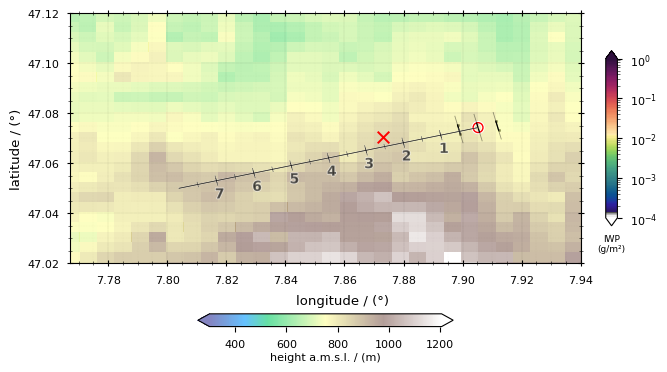

In [ ]:
# Initialize plot
os.makedirs(png_path, exist_ok=True)
fig, ax = setup_plot_lat_lon(cfg)
add_annotations(ax, cfg)

# Create base layers
pm_surf = ax.pcolormesh(lon2D, lat2D, height, cmap='terrain', vmin=300, alpha=0.6, zorder=1)
pm_qi = ax.pcolormesh(mod_latlon.longitude2D, mod_latlon.latitude2D, IWC[100, :, :], cmap=new_fjet2, norm=LogNorm(*cfg['v_lims_qi']), zorder=50, label='IWP')

pmesh = [pm_qi, pm_surf]
cell_plots = []

# Add labels
fig.text(0.5, 0.18, 'longitude / (°)', ha='center', va='center', fontsize=cfg['axis_size'])
fig.text(-0.01, 0.6, 'latitude / (°)', ha='center', va='center', fontsize=cfg['axis_size'], rotation='vertical')

# Add colorbars
cbars = add_colorbars(fig, ax, pmesh, cfg)
if True:

    # Clean output directory
    for pattern in ['*.png']:
        for f in glob.glob(os.path.join(png_path, pattern)):
            os.remove(f)
    print(f"Cleaned output directory: {png_path}")
    
    # Generate frames in parallel
    def render_frame(iframe):
        update_frame(iframe, fig, ax, pmesh, cell_plots, cfg, mod.time.values, IWC, 'area', cell_tracks_qi, cell_tracks_qs)
    
    with multiprocessing.Pool(cfg['poolsize']) as pool:
        pool.map(render_frame, range(IWC.shape[0]))
    
    print('All frames created')
    
    # Create video and gif
    input_pattern = os.path.join(png_path, f"lat_lon_frame_%03d_{cfg['resolution']}_area.png")
    output_mp4 = os.path.join(png_path, f"lat_lon_{flare_exp_name}_{cfg['resolution']}.mp4")
    output_gif = output_mp4.replace('.mp4', '.gif')
    
    tools.convert_to_video(input_pattern, output_mp4, resolution="1920:1080", loop_count=2, framerate=15)
    tools.convert_to_gif(input_pattern, output_gif, scale_factor=0.5, fps=20)
    
    print(f"Created: {os.path.abspath(output_mp4)}")
    print(f"Created: {os.path.abspath(output_gif)}")

In [10]:
print(f"Created: {os.path.abspath(output_mp4)}")
print(f"Created: {os.path.abspath(output_gif)}")

Created: /home/b/b382237/code/jupyterhub_nbs/QL-TopView/cs-eriswil__20260210_113944/pngs/lat_lon_20260210114328_400m.mp4
Created: /home/b/b382237/code/jupyterhub_nbs/QL-TopView/cs-eriswil__20260210_113944/pngs/lat_lon_20260210114328_400m.gif


# Generate lat-height plot (vertical profiles)

In [ ]:
# Compute spatially-integrated water contents over time
# These will be used for the top subplot showing temporal evolution

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
def compute_integrated_water_contents(ds_3d):
    """
    Compute domain-integrated water contents over time.
    Returns time series of IWC, LWC, SWC, TWC in kg.
    """
    # Select relevant altitude range
    dss = ds_3d[['qc', 'qi', 'qs', 'qv', 'dz']]
    wc = {
        'IWC': (dss['qi'] * dss['dz'] * cfg['delta_x'] * cfg['delta_y']).sum(['altitude', 'longitude', 'latitude']),
        'LWC': (dss['qc'] * dss['dz'] * cfg['delta_x'] * cfg['delta_y']).sum(['altitude', 'longitude', 'latitude']),
        'SWC': (dss['qs'] * dss['dz'] * cfg['delta_x'] * cfg['delta_y']).sum(['altitude', 'longitude', 'latitude']),
        'VC':  (dss['qv'] * dss['dz'] * cfg['delta_x'] * cfg['delta_y']).sum(['altitude', 'longitude', 'latitude']),
    }
    wc.update({
        'TWC': wc['IWC'] + wc['LWC'] + wc['VC'],
        'TIWC': wc['IWC'] + wc['SWC']
    })
    return xr.Dataset(wc)



def setup_plot_with_timeseries(cfg):
    """
    Initialize figure with two subplots:
    - Top: Time series of water contents (25% height)
    - Bottom: Latitude-height cross section (100% height)
    """
    plt.style.use('seaborn-v0_8-paper')
    
    # Calculate figure dimensions
    total_width = cfg['pixel_size'][0] / cfg['dpi']
    main_height = cfg['pixel_size'][1] / 300
    ts_height = main_height * 0.33  # Time series subplot is 33% of main height
    
    # Create figure with gridspec for custom sizing
    fig = plt.figure(figsize=(total_width, main_height + ts_height), constrained_layout=True)
    
    # Create gridspec: 2 rows with height ratio 1:4 (33% : 100%)
    gs      = fig.add_gridspec(2, 1, height_ratios=[1, 3], hspace=0.05)
    ax_ts   = fig.add_subplot(gs[0])  # Time series on top
    ax_main = fig.add_subplot(gs[1])  # Main vertical profile
    
    # Configure main axis
    ax_main.set_ylim((600, 1400))
    set_name_tick_params(ax_main)
    
    # Configure time series axis
    set_name_tick_params(ax_ts)

    # Create inset axis for histogram in top right of lat-height plot
    ax_hist = inset_axes(ax_main, width="30%", height="40%", loc='upper right', 
                         bbox_to_anchor=(-0.05, -0.05, 1.0, 1.0), bbox_transform=ax_main.transAxes)
    ax_hist.tick_params(axis='both', which='major', labelsize=cfg['tick_size']-2)
    # ax_hist.set_xlabel('diameter', fontsize=cfg['tick_size']-1)
    # ax_hist.set_ylabel('cumulative\ncount', fontsize=cfg['tick_size']-1)
    # ax_hist.set_xlim()
    ax_hist.patch.set_alpha(0.8)
    

    return fig, ax_main, ax_ts


def plot_timeseries_dual_axis(ax_ts, water_contents, current_time, cfg):
    """
    Alternative version with dual y-axes for greatly different scales.
    """
    from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
    ax_ts.clear()
    
    time = water_contents['IWC'].time.values
    
    # Left axis: IWC, SWC, TWC (typically larger values)
    colors_left = {'IWC': '#2E86AB', 'SWC': '#F18F01', 'TIWC': '#000000', }
    lines = []
    labels = ['IWC', 'SWC', 'TIWC']
    for key in labels:
        line, = ax_ts.plot(time, water_contents[key].values*1e-3,
                          color=colors_left[key],
                          linewidth=2.0 if key == 'TWC' else 1.5,
                          alpha=1.0 if key == 'TWC' else 0.9,
                          label=key,
                          )
        lines.append(line)
    
    # Add vertical line for current time
    ax_ts.axvline(current_time, color='black', linestyle='--', linewidth=1, alpha=0.75, zorder=10)

    ax_ts.set_xlim(time[0], time[-1])
    ax_ts.set_xlabel('time / (UTC)', fontsize=cfg['axis_size'], color='black')
    ax_ts.set_ylabel('ice mass / (kg)', fontsize=cfg['axis_size'], color='black')
    ax_ts.set_axisbelow(True)
    ax_ts.ticklabel_format(axis='y', style='scientific', scilimits=(-3, +3))
        # Formatting
    ax_ts.xaxis.set_major_formatter(md.DateFormatter('%H:%M'))
    ax_ts.xaxis.set_minor_locator(AutoMinorLocator())
    ax_ts.yaxis.set_minor_locator(AutoMinorLocator())
    ax_ts.tick_params(axis='both', which='major', direction='inout', top=True, right=True, labelsize=cfg['tick_size'])
    ax_ts.tick_params(axis='both', which='minor', direction='inout', top=True, right=True, labelsize=cfg['tick_size'])
    
    ax_ts.grid(which='both', linestyle='--', alpha=0.15, linewidth=0.5, color='black')
    ax_ts.grid(which='minor', linestyle='--', alpha=0.05, linewidth=0.25, color='black')

    
    
    ax_ts.legend(lines, labels, loc='upper left', ncol=4, fontsize=cfg['tick_size'], framealpha=0.9, edgecolor='none')
    

def update_frame_enhanced(iframe, fig, ax_main, ax_ts, pmesh, cfg, time_values, IWC_lat, water_contents):
    """
    Update both subplots for animation frame.
    """
    # Clear previous timer text
    for txt in fig.texts:
        if 'UTC' in txt.get_text():
            txt.set_visible(False)
    
    # Update main plot (vertical profile)
    pmesh[0].set_array(IWC_lat[iframe, :, :].flatten())
    
    # Update time series plot
    current_time = time_values[iframe]
    # plot_timeseries(ax_ts, water_contents, current_time, cfg)
    plot_timeseries_dual_axis(ax_ts, water_contents, current_time, cfg)
    
    # Add timer
    timer_str = np.datetime_as_string(current_time, unit='s').replace('T', '  ')
    fig.text(0.96, 0.99, f'{timer_str[-8:]} UTC', ha='right', va='top', fontweight='semibold', fontsize=cfg['timer_size'])
    
    # Save frame
    out_file = f"{png_path}/lat_height_frame_{iframe:03d}_{cfg['resolution']}.png"
    fig.savefig(out_file, dpi=cfg['dpi'], bbox_inches='tight')


def hist2d(mod, seg_mask, n_bins=40):
    # Apply mask: keep only qf values where mask > 0
    masked_qf = np.where(seg_mask > 0, (mod['qi'] + mod['qs']), 0.0)
    masked_qc = np.where(seg_mask > 0, (mod['qc']), 0.0)
    
    
    masked_qf_t_flat = masked_qf[:, :, :].flatten()
    masked_qc_t_flat = masked_qc[:, :, :].flatten()
    
    masked_qf_t_flat = masked_qf_t_flat[masked_qf_t_flat > 0]
    masked_qc_t_flat = masked_qc_t_flat[masked_qc_t_flat > 0]
        
    if (len(masked_qf_t_flat) == 0) and (len(masked_qc_t_flat) == 0):
        # No data in mask, return zeros
        hist_counts, xbin_edges, ybin_edges = np.linspace(0, 1, n_bins), np.linspace(0, 1, n_bins), np.zeros((n_bins, n_bins))
    else:
        # Compute histogram
        hist_counts, xbin_edges, ybin_edges = np.histogram2d(masked_qc_t_flat, masked_qf_t_flat, bins=100)
        
    xbin_centers = (xbin_edges[:-1] + xbin_edges[1:]) / 2
    ybin_centers = (ybin_edges[:-1] + ybin_edges[1:]) / 2
    return hist_counts, xbin_centers, ybin_centers



# Load data for side view

In [ ]:
data_extpar      = xr.open_mfdataset(extpar_file, chunks='auto')
lat1D            = data_extpar['lat'].mean('rlon').values[7:-7]
surf_height      = data_extpar['HSURF'].values[7:-7, 7:-7]
surf_height_mean = data_extpar['HSURF'].mean('rlon').values[7:-7]

n_cut_lat, n_cut_lon = surf_height.shape
print('lon', n_cut_lon, 'lat', n_cut_lat )

mod_lat = ds_3d[['qi', 'qs', 'qc', 'qv']].sel( 
    latitude=slice(None, cfg['flare_lat'] + 2.*cfg['resolution_deg']), 
    longitude=slice(None, cfg['flare_lon'] + 2.*cfg['resolution_deg']) )
mod_lat = xr.where(mod_lat < 1e-6, np.nan, mod_lat)
mod_lat = ( mod_lat * cfg['delta_x'] ).sum('longitude')

height3D = ds_3d.altitude3D.sel( latitude=slice(None, cfg['flare_lat'] + 2.*cfg['resolution_deg']), 
                                longitude=slice(None, cfg['flare_lon'] + 2.*cfg['resolution_deg']) )
# prepare data for tobac quicklook
with ProgressBar() as pbar:
    mod_lat = mod_lat.persist()
    height3D = height3D.persist()

# Prepare plotting data
height1D = mod_lat.altitude.values

IWC_lat = (mod_lat['qi'] + mod_lat['qs']).values

lon 36 lat 26
[########################################] | 100% Completed | 35.66 s
[########################################] | 100% Completed | 202.97 ms


Data variables:
    hhl      (time, altitude) float64 37kB dask.array<chunksize=(1, 20), meta=np.ndarray>
    rho      (time, altitude) float64 37kB dask.array<chunksize=(1, 20), meta=np.ndarray>
    qi       (time, altitude) float64 37kB dask.array<chunksize=(1, 20), meta=np.ndarray>
    qc       (time, altitude) float64 37kB dask.array<chunksize=(1, 20), meta=np.ndarray>
    qs       (time, altitude) float64 37kB dask.array<chunksize=(1, 20), meta=np.ndarray>
    qv       (time, altitude) float64 37kB dask.array<chunksize=(1, 20), meta=np.ndarray>
    qr       (time, altitude) float64 37kB dask.array<chunksize=(1, 20), meta=np.ndarray>
    dz       (time, altitude) float64 37kB dask.array<chunksize=(1, 20), meta=np.ndarray>
    t        (time, altitude) float64 37kB dask.array<chunksize=(1, 20), meta=np.ndarray>
    nf       (time, altitude) float64 37kB dask.array<chunksize=(1, 20), meta=np.ndarray>
    nw       (time, altitude) float64 37kB dask.array<chunksize=(1, 20), meta=np.nda

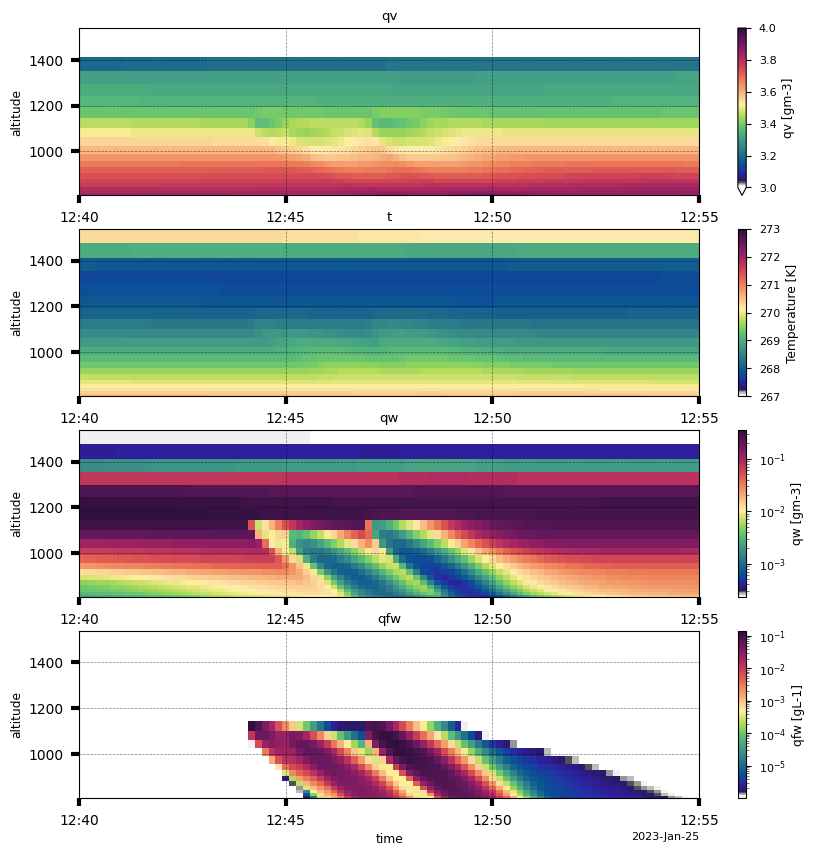

In [ ]:
# # create histogram plot
# from scipy import stats

# from xhistogram.xarray import histogram

# color_by = True
# Nbins = 50


# da_v1 = (mod_lat.qi + mod_lat.qs)
# da_v1 = xr.where(da_v1>1e-7, da_v1, 1e-7)
# da_v1.name = 'qi+qs'

# da_v2   = (mod_lat.qc)
# da_v2 = xr.where(da_v2>1e-2, da_v2, 1e-2)
# da_v2.name = 'qc'

# da_v3   = (mod_lat.qv)
# da_v3 = xr.where(da_v3>1e+4, da_v3, 1e5)
# da_v3.name = 'qv'





# H_list = []
# for iframe in range(da_v1.time.size//2, da_v1.time.size, 4):
    
#     s, i, r, p, std_err = stats.linregress(var1, var2)
#     #print('\n\niframe=',iframe)
#     #print(s, i, r, p, std_err)
#     # start function here?
#     var1 = da_v1.isel(time=140).values
#     var2 = da_v2.isel(time=140).values
#     var3 = da_v3.isel(time=140).values
    
#     combined_mask = xr.ufuncs.logical_or(var1 > 0, var2 > 0)
    
#     var1 = var1[combined_mask].ravel()  # +4.5
#     var2 = var2[combined_mask].ravel()
    
#     if color_by:
#         var3 = var3[combined_mask].ravel()
#         print(var1.shape, var2.shape, var3.shape)
#     else:
#         print(var1.shape, var2.shape)
    
    
#     x_lim_lin = [np.nanmin(var1), np.nanmax(var1)]
#     y_lim_lin = [np.nanmin(var2), np.nanmax(var2)]
#     x_lim_log = [np.log10(np.nanmin(var1)), np.log10(np.nanmax(var1))]
#     y_lim_log = [np.log10(np.nanmin(var2)), np.log10(np.nanmax(var2))]
    
#     v1_bins = np.logspace(*x_lim_log, 20)
#     v2_bins  = np.logspace(*y_lim_log, 20)

#     # H, xedges, yedges = np.histogram2d(var1, var2, bins=Nbins, range=[x_lim_lin, y_lim_lin])
#     H = histogram( da_v1.isel(time=iframe), da_v1.isel(time=iframe), bins=[v1_bins, v2_bins] )
#     H_list.append(H)

# H_list = np.array(H_list)
# # hTSs = []
# # for iframe in range(qiqs.time.size):
# #     hTS = histogram( qiqs.isel(time=iframe), qc.isel(time=iframe), bins=[iwc_bins, qc_bins] )
# #     hTSs.append(hTS)

# # hTSs = xr.concat(hTSs, dim='time' )

# # hTSs = hTSs.assign_coords({'time': qiqs.time})
# # hTSs
    
# H = np.ma.masked_less_equal(H_list, 0)

In [ ]:

    
# color_by=False
# if color_by:

#     H_new_list = []
    
#     print(f"Coloring scatter plot by {qv.name}...\n")
#     # overwrite H
#     for iframe in range(da_v1.time.size//2, da_v1.time.size, 4):
    
        
#         H = np.zeros((Nbins, Nbins))
        
#         # get the bins of the 2d histogram using digitize
#         x_coords = np.digitize(var1, xedges)
#         y_coords = np.digitize(var2, yedges)
#         # find unique bin combinations = pixels in scatter plot
    
#         # sort x and y coordinates using lexsort
#         # lexsort sorts by multiple columns, first by y_coords then by x_coords
    
#         newer_order = np.lexsort((x_coords, y_coords))
#         x_coords = x_coords[newer_order]
#         y_coords = y_coords[newer_order]
#         var3     = var3[newer_order]
        
#         first_hit_y = np.searchsorted(y_coords, np.arange(1, Nbins + 2))
#         first_hit_y.sort()
        
#         first_hit_x = []
#         for j in np.arange(Nbins):
#             next_hit_y = np.searchsorted( x_coords[first_hit_y[j]:first_hit_y[j + 1]], np.arange(1, Nbins + 2) )
#             first_hit_x.append( next_hit_y + first_hit_y[j])
    
#         for x in range(Nbins):
#             for y in range(Nbins):
#                 H[y, x] = np.nanmedian(var3[first_hit_x[x][y]: first_hit_x[x][y + 1]])

#         H_new_list.append(H)

#     from matplotlib.ticker import AutoMinorLocator

    
#     X, Y = np.meshgrid(xedges, yedges)
#     fig, ax = plt.subplots(1, figsize=(10, 10))
    
#     c_lim = [1e4, 1e6]
    
    
#     formstring = "%.2E"
#     pcol = ax.pcolormesh(X, Y, np.transpose(H), norm=LogNorm(vmin=c_lim[0], vmax=c_lim[1]), cmap=colormap)
    
#     ax.xaxis.set_minor_locator(AutoMinorLocator())
#     ax.yaxis.set_minor_locator(AutoMinorLocator())
    
#     cmap = new_fjet2
#     #cmap.set_under('white', 1.0)
#     formstring = kwargs['formstring'] if 'formstring' in kwargs else formstring
#     cbar = fig.colorbar(pcol, use_gridspec=True, extend='min', extendrect=True, extendfrac=0.01, shrink=0.8, format=formstring)
#     if color_by:
#         cbar.set_label(label=f"median {da_v3.name} [{da_v3.units}]", fontweight='normal', fontsize='12')
#     else:
#         cbar.set_label(label="frequency of occurrence", fontweight=fontweight, fontsize=fontsize)
        
#     cbar.mappable.set_clim(c_lim)
#     cbar.aspect = 50
    
#     #ax.set_yscale('log')
#     ax.set_xscale('log')
    
#     plt.grid(which='both', color='black', linestyle='--', linewidth=0.5, alpha=0.5)
#     ax.yaxis.set_minor_locator(AutoMinorLocator())
#     ax.tick_params(axis='both', which='both', right=True, top=True)
#     ax.tick_params(axis='both', which='major', labelsize=10, width=3, length=5.5)
#     ax.tick_params(axis='both', which='minor', width=2, length=3)
#     if 'colorbar' in kwargs and kwargs['colorbar']:
#         cbar.ax.tick_params(axis='both', which='major', labelsize=10, width=2, length=4)
    
    
        
#     hTSs = []
#     for iframe in range(qiqs.time.size):
#         hTS = histogram( qiqs.isel(time=iframe), qc.isel(time=iframe), bins=[iwc_bins, qc_bins] )
#         hTSs.append(hTS)
    
    
#     hTSs = xr.concat(hTSs, dim='time' )
#     hTSs = hTSs.assign_coords({'time': qiqs.time})
#     hTSs

In [ ]:
# xr.where(hTSs>0, hTSs, 1e-1).sum('time').plot(xscale='log', yscale='log', norm=LogNorm())

In [ ]:
def compute_integrated_water_contents(ds_3d):
    """
    Compute domain-integrated water contents over time.
    Returns time series of IWC, LWC, SWC, TWC in kg.
    """
    # Select relevant altitude range
    dss = ds_3d[['qc', 'qi', 'qs', 'qv', 'dz']]
    wc = {
        'IWC': (dss['qi'] * dss['dz'] * cfg['delta_x'] * cfg['delta_y']).sum(['altitude', 'longitude', 'latitude']),
        'LWC': (dss['qc'] * dss['dz'] * cfg['delta_x'] * cfg['delta_y']).sum(['altitude', 'longitude', 'latitude']),
        'SWC': (dss['qs'] * dss['dz'] * cfg['delta_x'] * cfg['delta_y']).sum(['altitude', 'longitude', 'latitude']),
        'VC':  (dss['qv'] * dss['dz'] * cfg['delta_x'] * cfg['delta_y']).sum(['altitude', 'longitude', 'latitude']),
    }
    wc.update({
        'TWC': wc['IWC'] + wc['LWC'] + wc['VC'],
        'TIWC': wc['IWC'] + wc['SWC']
    })
    return xr.Dataset(wc)

# Compute water contents
water_contents = compute_integrated_water_contents(ds_3d)

with ProgressBar():
    water_contents = water_contents.persist()
        
print("Water content time series computed")
print(f"{'VAR':>5s}:  {'min':>10s},  {'max':>10s}")
print(f"{'-'*33}")
for key, val in water_contents.items():
    print(f"{key:>5s}:  {val.min().values:20.4f},  {val.max().values:20.4f}")

[########################################] | 100% Completed | 42.42 s
Water content time series computed
  VAR:         min,         max
---------------------------------
  IWC:                6.7514,           115229.6440
  LWC:      31015187799.9273,      31725728953.2436
  SWC:                0.0036,         19405367.5192
   VC:     659011034036.7601,     660941876188.0249
  TWC:     690736763125.0052,     692427946945.6252
 TIWC:                6.7551,         19517105.6547


Enhanced plot initialized


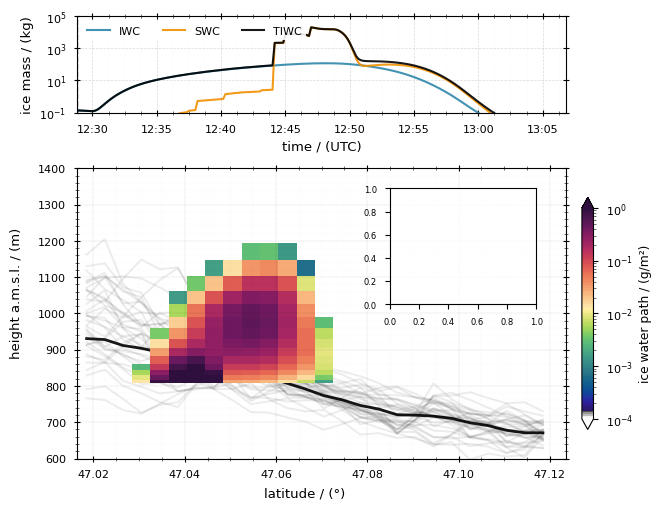

In [ ]:
# Initialize enhanced plot with time series
idx_time = 130
fig, ax_main, ax_ts = setup_plot_with_timeseries(cfg)

# Create base layers on main axis
pm_surf  = ax_main.plot(lat1D, surf_height_mean, color='black', alpha=0.9, linewidth=2)
pml_surf = ax_main.plot(lat1D, surf_height, color='black', alpha=0.035 if '100m' in cfg['resolution'] else 0.075)
pm_qi    = ax_main.pcolormesh(lat1D[:IWC_lat.shape[-1]], height1D, IWC_lat[idx_time, :, :], cmap=new_fjet2, norm=LogNorm(*cfg['v_lims_qi']), zorder=2, label='IWP')

pmesh = [pm_qi, pm_surf]

# Add labels
fig.text(0.45, -0.02, 'latitude / (°)', ha='center', va='center', fontsize=cfg['axis_size'], fontweight='normal')
fig.text(0.0, 0.4, 'height a.m.s.l. / (m)', ha='center', va='center', fontsize=cfg['axis_size'], fontweight='normal', rotation='vertical')

# Add colorbar for main plot
cb_qi = fig.colorbar(pm_qi, ax=ax_main, pad=0.025, extend='both', shrink=0.8, aspect=20, label='ice water path / (g/m²)')
cb_qi.ax.tick_params(labelsize=cfg['tick_size'])

# Plot initial time series
#water_contents['TIWC'] = (water_contents['IWC'].cumsum('time') + water_contents['SWC'].cumsum('time'))*cfg['delta_t']
plot_timeseries_dual_axis(ax_ts,  water_contents, mod_lat.time.values[0], cfg)
ax_ts.set_yscale('log')
ax_ts.set_ylim((1.0e-1, 1e5))
print("Enhanced plot initialized")

In [ ]:
if cfg['plot_all_frames'] and True:
    # Clean output directory
    os.makedirs(png_path, exist_ok=True)
    for f in glob.glob(os.path.join(png_path, '*.png')):
        os.remove(f)
    print(f"Cleaned output directory: {png_path}")
    
    # Generate frames in parallel
    def render_frame(iframe):
        update_frame_enhanced(iframe, fig, ax_main, ax_ts, pmesh, cfg, mod_lat.time.values, IWC_lat, water_contents)
    
    with multiprocessing.Pool(cfg['poolsize']) as pool:
        pool.map(render_frame, range(IWC_lat.shape[0]))
    
    print('All frames created')
    
    # Create video and gif
    input_pattern = os.path.join(png_path, f"lat_height_frame_%03d_{cfg['resolution']}.png")
    output_mp4 = os.path.join(png_path, f"lat_height_3d_{flare_exp_name}_{cfg['resolution']}.mp4")
    output_gif = output_mp4.replace('.mp4', '.gif')
    
    tools.convert_to_video(input_pattern, output_mp4, resolution="1920:1080", loop_count=2, framerate=20)
    tools.convert_to_gif(input_pattern, output_gif, scale_factor=0.5, fps=10)
    
    print(f"Created: {output_mp4}")
    print(f"Created: {output_gif}")
else:
    
    # Test single frame first
    iframe_test = 50
    update_frame_enhanced(iframe_test, fig, ax_main, ax_ts, pmesh, cfg, mod_lat.time.values, IWC_lat, water_contents)
    print(f"Test frame {iframe_test} rendered")
    print("Set cfg['plot_all_frames'] = True to generate full animation")

Cleaned output directory: QL-TopView/cs-eriswil__20260127_211338/pngs/
All frames created
FFMPEG created MP4 file: /home/b/b382237/code/jupyterhub_nbs/QL-TopView/cs-eriswil__20260127_211338/pngs/lat_height_3d_20260127211431_400m.mp4
FFMPEG created GIF file: /home/b/b382237/code/jupyterhub_nbs/QL-TopView/cs-eriswil__20260127_211338/pngs/lat_height_3d_20260127211431_400m.gif
Created: QL-TopView/cs-eriswil__20260127_211338/pngs/lat_height_3d_20260127211431_400m.mp4
Created: QL-TopView/cs-eriswil__20260127_211338/pngs/lat_height_3d_20260127211431_400m.gif
